### This notebook performs exploratory data analysis on the aggregated monthly dataset to understand patterns in airline disruptions. It examines temporal trends, airline and airport-level variations, and the distribution of key operational metrics, providing insights that inform feature engineering and model development.

# Imports

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load the Monthly Aggregated Dataset

In [2]:
# Define the file path for the processed monthly dataset
parquet_path = Path("../data/processed/final_monthly_operational_summary_data.parquet")

# Load the dataset from parquet if available, otherwise load from CSV

eda_df = pd.read_parquet(parquet_path)

# Convert YearMonth to datetime format
eda_df['YearMonth'] = pd.to_datetime(eda_df['YearMonth'])

# Preview the dataset
eda_df.head()

,YearMonth,Reporting_Airline,Origin,total_completed_flights,dep_delayed_flights,arr_delayed_flights,disrupted_flights,avg_dep_delay,avg_arr_delay,median_dep_delay,...,security_delay_minutes,late_aircraft_delay_minutes,pct_dep_delayed,pct_arr_delayed,pct_disrupted,total_scheduled_flights,cancelled_flights,diverted_flights,pct_cancelled,pct_diverted
0,2023-01-01,9E,ABE,15,2,2,2,24.666667,11.533333,-5.0,...,0.0,291.0,0.133333,0.133333,0.133333,15,0.0,0.0,0.000000,0.0
1,2023-01-01,9E,ABY,82,12,13,14,11.073171,8.500000,-5.0,...,0.0,874.0,0.146341,0.158537,0.170732,82,0.0,0.0,0.000000,0.0
2,2023-01-01,9E,AEX,58,11,10,11,20.758621,10.827586,-5.0,...,0.0,1217.0,0.189655,0.172414,0.189655,60,2.0,0.0,0.033333,0.0
3,2023-01-01,9E,AGS,26,7,7,7,24.846154,15.038462,-0.5,...,0.0,113.0,0.269231,0.269231,0.269231,26,0.0,0.0,0.000000,0.0
4,2023-01-01,9E,ALB,107,21,32,34,8.570093,9.130841,-5.0,...,0.0,827.0,0.196262,0.299065,0.317757,110,3.0,0.0,0.027273,0.0


# Check the Structure of the Dataset

In [3]:
eda_df.shape

(55077, 24)

In [5]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55077 entries, 0 to 55076
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   YearMonth                    55077 non-null  datetime64[ns]
 1   Reporting_Airline            55077 non-null  object        
 2   Origin                       55077 non-null  object        
 3   total_completed_flights      55077 non-null  int64         
 4   dep_delayed_flights          55077 non-null  int64         
 5   arr_delayed_flights          55077 non-null  int64         
 6   disrupted_flights            55077 non-null  int64         
 7   avg_dep_delay                55077 non-null  float64       
 8   avg_arr_delay                55077 non-null  float64       
 9   median_dep_delay             55077 non-null  float64       
 10  median_arr_delay             55077 non-null  float64       
 11  carrier_delay_minutes        55077 non-nu

In [6]:
eda_df.isnull().sum()

YearMonth                      0
Reporting_Airline              0
Origin                         0
total_completed_flights        0
dep_delayed_flights            0
arr_delayed_flights            0
disrupted_flights              0
avg_dep_delay                  0
avg_arr_delay                  0
median_dep_delay               0
median_arr_delay               0
carrier_delay_minutes          0
weather_delay_minutes          0
nas_delay_minutes              0
security_delay_minutes         0
late_aircraft_delay_minutes    0
pct_dep_delayed                0
pct_arr_delayed                0
pct_disrupted                  0
total_scheduled_flights        0
cancelled_flights              0
diverted_flights               0
pct_cancelled                  0
pct_diverted                   0
dtype: int64

# Create Year and Month Variables

In [7]:
# Extract year and month number from the YearMonth column
eda_df['Year'] = eda_df['YearMonth'].dt.year
eda_df['MonthNum'] = eda_df['YearMonth'].dt.month
eda_df['MonthName'] = eda_df['YearMonth'].dt.strftime('%b')

# Preview the new date-related columns
eda_df[['YearMonth', 'Year', 'MonthNum', 'MonthName']].head()

,YearMonth,Year,MonthNum,MonthName
0,2023-01-01,2023,1,Jan
1,2023-01-01,2023,1,Jan
2,2023-01-01,2023,1,Jan
3,2023-01-01,2023,1,Jan
4,2023-01-01,2023,1,Jan


# Basic Summary Statistics

In [8]:
# Display summary statistics for key numeric variables
eda_df[
    [
        'total_scheduled_flights',
        'cancelled_flights',
        'diverted_flights',
        'disrupted_flights',
        'pct_disrupted',
        'pct_cancelled',
        'pct_diverted',
        'avg_dep_delay',
        'avg_arr_delay'
    ]
].describe()

,total_scheduled_flights,cancelled_flights,diverted_flights,disrupted_flights,pct_disrupted,pct_cancelled,pct_diverted,avg_dep_delay,avg_arr_delay
count,55077.000000,55077.000000,55077.000000,55077.000000,55077.000000,55077.000000,55077.000000,55077.000000,55077.000000
mean,379.987508,5.213229,0.967863,91.335730,0.234520,0.015959,0.002636,13.465620,8.819463
std,1051.485878,22.706843,3.214834,296.968275,0.127256,0.028765,0.008939,17.485157,18.864498
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-42.142857,-54.000000
25%,52.000000,0.000000,0.000000,9.000000,0.150000,0.000000,0.000000,3.866667,-1.607477
50%,102.000000,1.000000,0.000000,22.000000,0.217391,0.004367,0.000000,10.014315,5.470588
75%,265.000000,3.000000,1.000000,58.000000,0.298969,0.020408,0.002088,18.563748,15.146939
max,21855.000000,1460.000000,110.000000,7891.000000,1.000000,0.500000,0.500000,900.000000,921.000000


# Count Unique Airlines and Airports

In [9]:
# Count the number of unique airlines and origin airports
print("Number of unique airlines:", eda_df['Reporting_Airline'].nunique())
print("Number of unique origin airports:", eda_df['Origin'].nunique())

Number of unique airlines: 15
Number of unique origin airports: 362


# Check Time Coverage

In [10]:
# Display the unique YearMonth values in sorted order
eda_df['YearMonth'].drop_duplicates().sort_values().reset_index(drop=True)

0    2023-01-01
1    2023-02-01
2    2023-03-01
3    2023-04-01
4    2023-05-01
5    2023-06-01
6    2023-07-01
7    2023-08-01
8    2023-09-01
9    2023-10-01
10   2023-11-01
11   2023-12-01
12   2024-01-01
13   2024-02-01
14   2024-03-01
15   2024-04-01
16   2024-05-01
17   2024-06-01
18   2024-07-01
19   2024-08-01
20   2024-09-01
21   2024-10-01
22   2024-11-01
23   2024-12-01
24   2025-01-01
25   2025-02-01
26   2025-03-01
27   2025-04-01
28   2025-05-01
29   2025-06-01
30   2025-07-01
31   2025-08-01
32   2025-09-01
33   2025-10-01
34   2025-11-01
35   2025-12-01
Name: YearMonth, dtype: datetime64[ns]

# Record Counts by Year

In [11]:
# Count the number of rows per year
eda_df['Year'].value_counts().sort_index()

Year
2023    18603
2024    18687
2025    17787
Name: count, dtype: int64

# Record Counts by Month

In [12]:
# Count the number of rows per YearMonth
eda_df['YearMonth'].value_counts().sort_index()

YearMonth
2023-01-01    1539
2023-02-01    1532
2023-03-01    1541
2023-04-01    1543
2023-05-01    1544
2023-06-01    1563
2023-07-01    1550
2023-08-01    1559
2023-09-01    1576
2023-10-01    1545
2023-11-01    1549
2023-12-01    1562
2024-01-01    1563
2024-02-01    1528
2024-03-01    1535
2024-04-01    1543
2024-05-01    1568
2024-06-01    1589
2024-07-01    1551
2024-08-01    1565
2024-09-01    1557
2024-10-01    1557
2024-11-01    1556
2024-12-01    1575
2025-01-01    1466
2025-02-01    1446
2025-03-01    1457
2025-04-01    1454
2025-05-01    1475
2025-06-01    1537
2025-07-01    1503
2025-08-01    1521
2025-09-01    1487
2025-10-01    1492
2025-11-01    1470
2025-12-01    1479
Name: count, dtype: int64

# Create a Helper Function for Plots

In [45]:
# Create a helper function to save plots
from pathlib import Path

def save_plot(filename):
    output_dir = Path("../reports/figures")
    output_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_dir / filename, dpi=300, bbox_inches='tight')

# Overall Monthly Trend Summary

In [13]:
# Aggregate the dataset to an overall monthly summary
monthly_trend_df = (
    eda_df
    .groupby('YearMonth', as_index=False)
    .agg(
        total_scheduled_flights=('total_scheduled_flights', 'sum'),
        cancelled_flights=('cancelled_flights', 'sum'),
        diverted_flights=('diverted_flights', 'sum'),
        disrupted_flights=('disrupted_flights', 'sum'),
        avg_dep_delay=('avg_dep_delay', 'mean'),
        avg_arr_delay=('avg_arr_delay', 'mean')
    )
)

# Create overall monthly rate metrics
monthly_trend_df['pct_disrupted'] = (
    monthly_trend_df['disrupted_flights'] / monthly_trend_df['total_scheduled_flights']
)

monthly_trend_df['pct_cancelled'] = (
    monthly_trend_df['cancelled_flights'] / monthly_trend_df['total_scheduled_flights']
)

monthly_trend_df['pct_diverted'] = (
    monthly_trend_df['diverted_flights'] / monthly_trend_df['total_scheduled_flights']
)

# Preview the monthly trend summary
monthly_trend_df.head()

,YearMonth,total_scheduled_flights,cancelled_flights,diverted_flights,disrupted_flights,avg_dep_delay,avg_arr_delay,pct_disrupted,pct_cancelled,pct_diverted
0,2023-01-01,538837,10295.0,1345.0,133669,14.696770,10.554269,0.248069,0.019106,0.002496
1,2023-02-01,502749,9019.0,983.0,108696,11.210163,6.014261,0.216203,0.017939,0.001955
2,2023-03-01,580322,7406.0,1383.0,154706,14.328016,11.169904,0.266586,0.012762,0.002383
3,2023-04-01,561440,9589.0,1602.0,143584,13.886890,9.762098,0.255742,0.017079,0.002853
4,2023-05-01,579958,3310.0,1218.0,122636,9.608734,4.108215,0.211457,0.005707,0.002100


# Plot Overall Monthly Disruption Rate

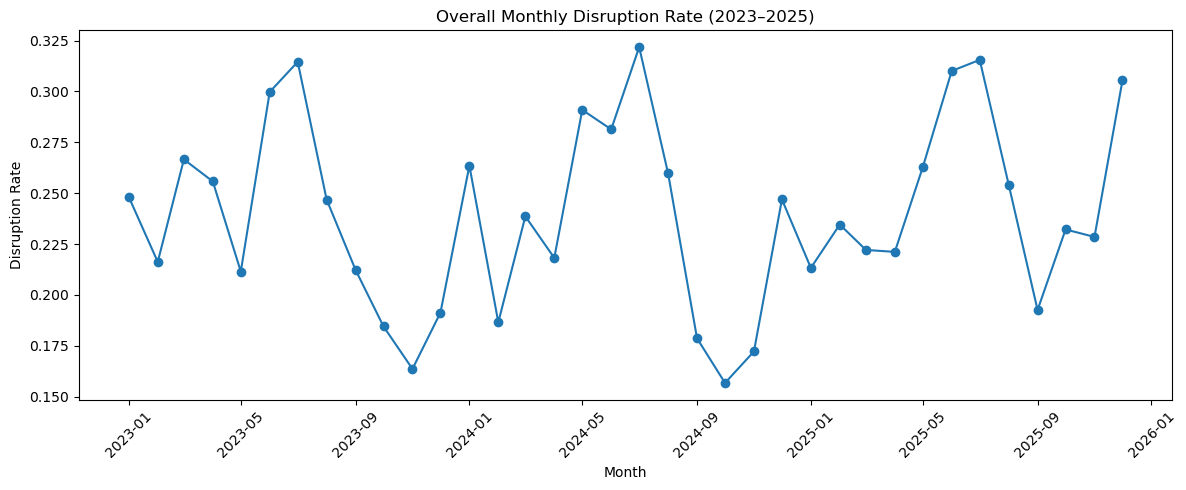

In [65]:
# Plot overall monthly disruption rate over time
plt.figure(figsize=(12, 5))
plt.plot(monthly_trend_df['YearMonth'], monthly_trend_df['pct_disrupted'], marker='o')
plt.xlabel('Month')
plt.ylabel('Disruption Rate')
plt.title('Overall Monthly Disruption Rate (2023–2025)')
plt.xticks(rotation=45)
plt.tight_layout()

save_plot("monthly_disruption_trend.png")
plt.show()

### Executive Summary: This confirms that airline disruptions follow a pronounced seasonal cycle, with critical risk peaks occurring every July and December. Over the three-year period, July consistently represented the annual maximum, reaching its highest point in 2024 (~0.32). On the other hand, the system regularly achieved its minimum disruption rates in the autumn months, specifically between September and October of each year. These findings prove that the volatility is not random but is a recurring problem.

# Plot Overall Monthly Cancellation Rate

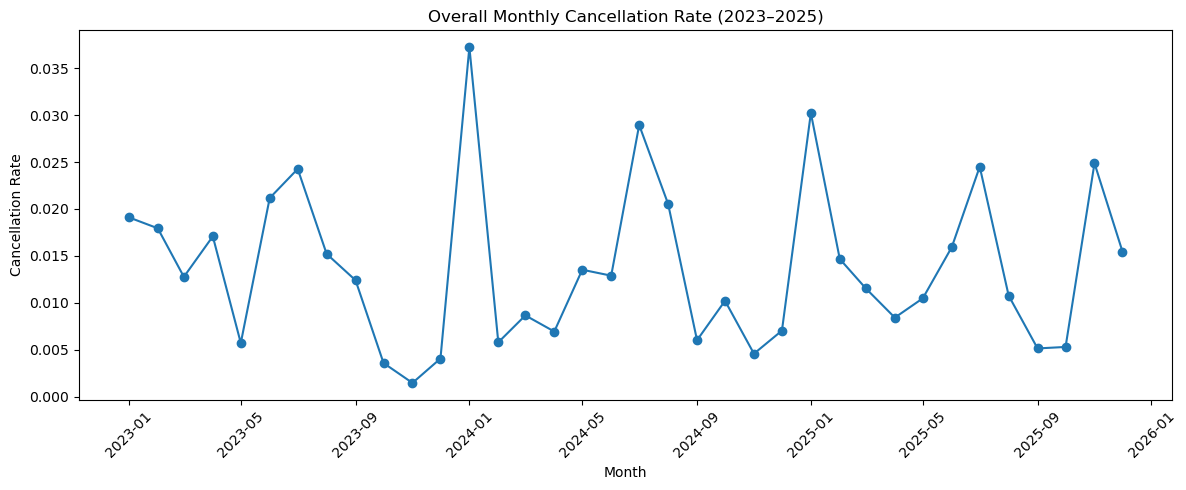

In [66]:
# Plot overall monthly cancellation rate over time
plt.figure(figsize=(12, 5))
plt.plot(monthly_trend_df['YearMonth'], monthly_trend_df['pct_cancelled'], marker='o')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate')
plt.title('Overall Monthly Cancellation Rate (2023–2025)')
plt.xticks(rotation=45)
plt.tight_layout()

save_plot("monthly_cancellation_trend.png")
plt.show()

### Executive Summary: This shows that airline cancellations follow a pronounced seasonal cycle, with the highest risk always occurring in January. Over the three-year period, January 2024 recorded the absolute maximum failure rate at nearly 0.038. In contrast, the system consistently hits its minimum cancellation rates in the late spring or early autumn, such as the record-low period seen in October 2023. These findings prove that while the summer is busy and full of delays, the winter is the main pressure point for total flight losses.

# Plot Overall Monthly Diversion Rate

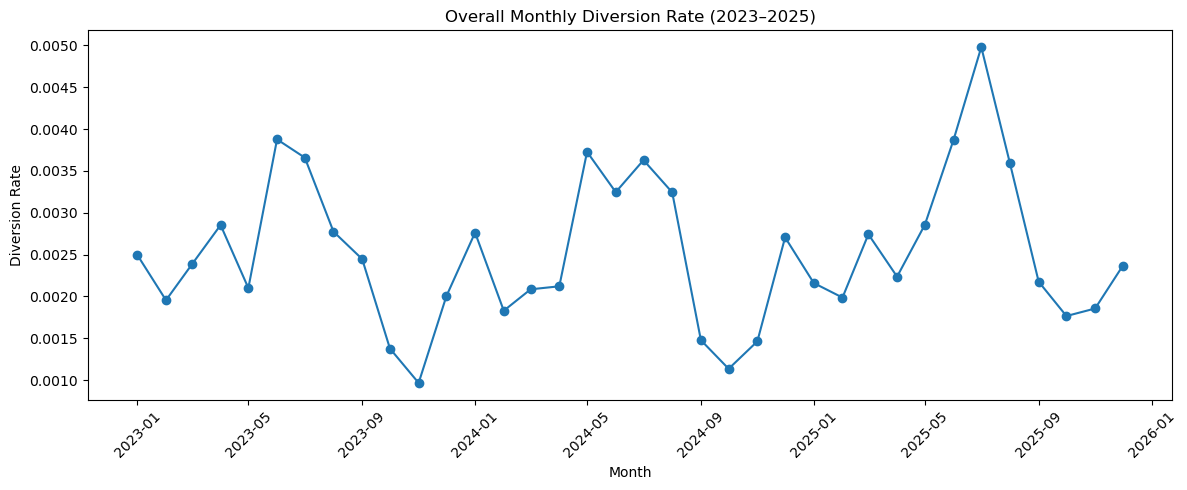

In [16]:
# Plot overall monthly diversion rate over time
plt.figure(figsize=(12, 5))
plt.plot(monthly_trend_df['YearMonth'], monthly_trend_df['pct_diverted'], marker='o')
plt.xlabel('Month')
plt.ylabel('Diversion Rate')
plt.title('Overall Monthly Diversion Rate (2023–2025)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Executive Summary: This confirms that flight diversions follow a pronounced seasonal cycle, with the highest risk consistently appearing in July. Over the three-year period, July 2025 recorded the absolute maximum diversion rate at 0.0050, showing that the problem is becoming more severe each year. In contrast, the system regularly hits its minimum diversion rates in October, which serves as the annual floor for this specific risk. These findings show that summer traffic and weather are the main pressure points for rerouting flights.

# Plot Overall Monthly Average Arrival Delay

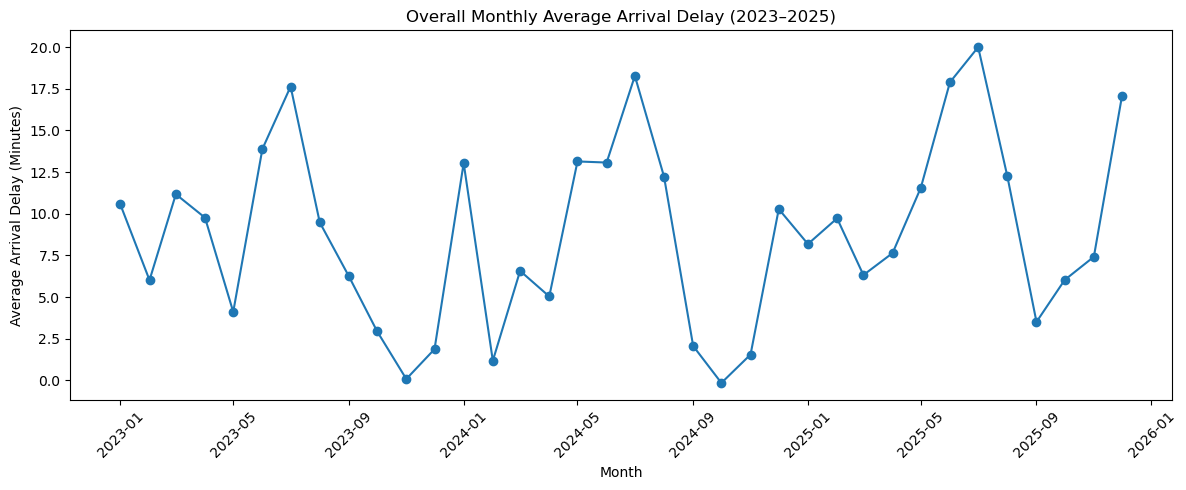

In [17]:
# Plot overall monthly average arrival delay over time
plt.figure(figsize=(12, 5))
plt.plot(monthly_trend_df['YearMonth'], monthly_trend_df['avg_arr_delay'], marker='o')
plt.xlabel('Month')
plt.ylabel('Average Arrival Delay (Minutes)')
plt.title('Overall Monthly Average Arrival Delay (2023–2025)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Executive Summary: This confirms that average arrival delays follow a pronounced seasonal cycle, with the longest wait times consistently occurring in July. Over the three-year period, July 2025 recorded the absolute maximum delay average at 20 minutes per flight, a steady increase from previous years. On the other hand, the system consistently hits its minimum delay duration in October, which serves as the annual floor for travel efficiency. These findings show that summer travel volume is the main pressure point for time-based performance.

# Yearly Summary Table

In [18]:
# Create a yearly summary table
yearly_summary_df = (
    eda_df
    .groupby('Year', as_index=False)
    .agg(
        total_scheduled_flights=('total_scheduled_flights', 'sum'),
        cancelled_flights=('cancelled_flights', 'sum'),
        diverted_flights=('diverted_flights', 'sum'),
        disrupted_flights=('disrupted_flights', 'sum'),
        avg_dep_delay=('avg_dep_delay', 'mean'),
        avg_arr_delay=('avg_arr_delay', 'mean')
    )
)

# Create yearly rate metrics
yearly_summary_df['pct_disrupted'] = (
    yearly_summary_df['disrupted_flights'] / yearly_summary_df['total_scheduled_flights']
)

yearly_summary_df['pct_cancelled'] = (
    yearly_summary_df['cancelled_flights'] / yearly_summary_df['total_scheduled_flights']
)

yearly_summary_df['pct_diverted'] = (
    yearly_summary_df['diverted_flights'] / yearly_summary_df['total_scheduled_flights']
)

# Display the yearly summary table
yearly_summary_df

,Year,total_scheduled_flights,cancelled_flights,diverted_flights,disrupted_flights,avg_dep_delay,avg_arr_delay,pct_disrupted,pct_cancelled,pct_diverted
0,2023,6847897,87943.0,16550.0,1607140,12.730556,7.810997,0.234691,0.012842,0.002417
1,2024,7079060,96314.0,17499.0,1668921,12.927646,8.050647,0.235755,0.013605,0.002472
2,2025,7001615,102872.0,19258.0,1754437,14.799601,10.681911,0.250576,0.014693,0.002751


# Plot Yearly Disruption Table

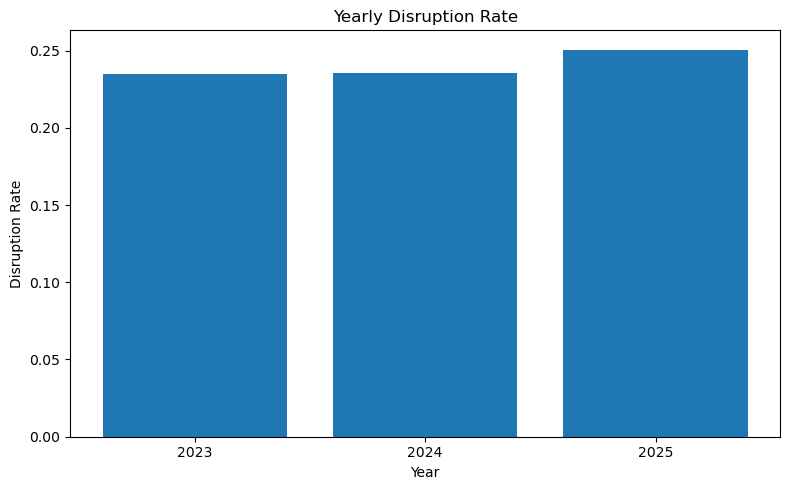

In [19]:
# Plot disruption rate by year
plt.figure(figsize=(8, 5))
plt.bar(yearly_summary_df['Year'].astype(str), yearly_summary_df['pct_disrupted'])
plt.xlabel('Year')
plt.ylabel('Disruption Rate')
plt.title('Yearly Disruption Rate')
plt.tight_layout()
plt.show()

### Executive Summary: This shows that airline disruptions are steadily increasing, with 2025 recording the annual maximum disruption rate of 0.25. While 2023 and 2024 stayed relatively stable at a minimum of approximately 0.235, the jump in 2025 indicates that operational pressure is beginning to outpace current system capacity. In contrast to the monthly charts that show seasonal dips, this yearly view confirms that the overall environment is becoming more volatile. These findings show that the "domino effect" of delays is a recurring problem that is growing in scale.

# Plot Yearly Cancellation Rate

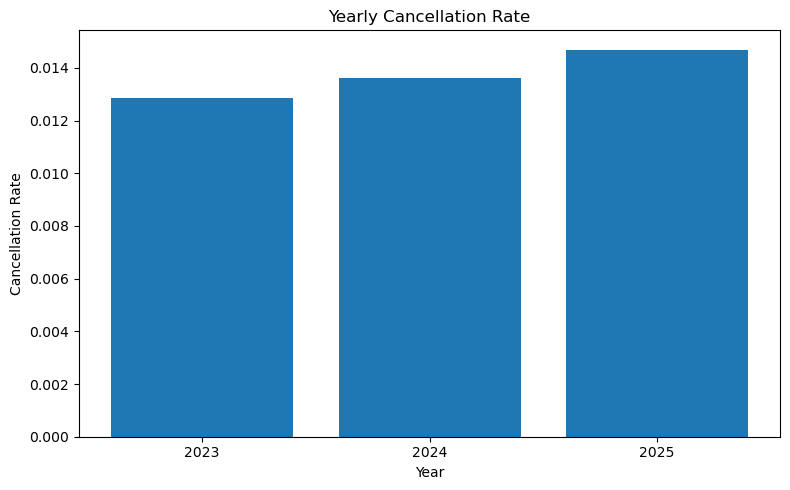

In [21]:
# Plot cancellation rate by year
plt.figure(figsize=(8, 5))
plt.bar(yearly_summary_df['Year'].astype(str), yearly_summary_df['pct_cancelled'])
plt.xlabel('Year')
plt.ylabel('Cancellation Rate')
plt.title('Yearly Cancellation Rate')
plt.tight_layout()
plt.show()

### Executive Summary: This shows that airline cancellations are steadily climbing, with 2025 reaching an annual maximum rate of nearly 0.015. While 2023 represented the yearly minimum at roughly 0.013, each subsequent year has seen a consistent increase in total flight scrubbing. This upward trend confirms that the overall environment is becoming more volatile, as the system struggles to absorb operational shocks. These findings show that the domino effect of delays is increasingly leading to complete cancellations rather than just late arrivals.

# Seasonality Analysis by Month Number

In [23]:
# Aggregate average performance by calendar month across all years
seasonality_df = (
    eda_df
    .groupby(['MonthNum', 'MonthName'], as_index=False)
    .agg(
        avg_pct_disrupted=('pct_disrupted', 'mean'),
        avg_pct_cancelled=('pct_cancelled', 'mean'),
        avg_pct_diverted=('pct_diverted', 'mean'),
        avg_arr_delay=('avg_arr_delay', 'mean')
    )
    .sort_values('MonthNum')
)

# Display the seasonality table
seasonality_df

,MonthNum,MonthName,avg_pct_disrupted,avg_pct_cancelled,avg_pct_diverted,avg_arr_delay
0,1,Jan,0.254180,0.032779,0.002401,10.643197
1,2,Feb,0.215480,0.016158,0.001796,5.564095
2,3,Mar,0.233619,0.013372,0.002372,8.053208
3,4,Apr,0.220018,0.013309,0.002694,7.475213
4,5,May,0.236793,0.011658,0.002932,9.589554
5,6,Jun,0.281755,0.018860,0.003884,14.923399
6,7,Jul,0.302088,0.027850,0.004327,18.621698
7,8,Aug,0.249500,0.017392,0.003635,11.313503
8,9,Sep,0.189527,0.008910,0.002531,3.951056
9,10,Oct,0.185580,0.007708,0.001265,2.892742


# Plot Seasonal Disruption Pattern

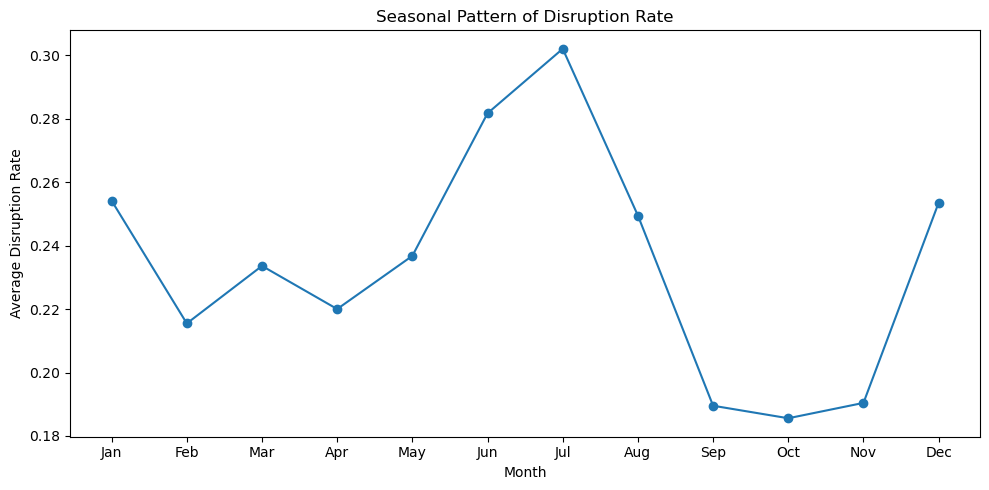

In [67]:
# Plot average disruption rate by calendar month
plt.figure(figsize=(10, 5))
plt.plot(seasonality_df['MonthName'], seasonality_df['avg_pct_disrupted'], marker='o')
plt.xlabel('Month')
plt.ylabel('Average Disruption Rate')
plt.title('Seasonal Pattern of Disruption Rate')
plt.tight_layout()

save_plot("seasonality_disruption.png")
plt.show()

### Executive Summary: This confirms that airline disruptions follow a very predictable seasonal curve. The system reaches its annual maximum in July (~0.30), driven by peak summer travel and storm activity. On the other hand, the system consistently hits its minimum disruption rate in October (~0.185), which is the most stable month for operations. A secondary risk spike occurs in December, showing that the winter holiday season is a recurring problem for flight stability. These findings prove that the environment is most volatile during the extreme heat of summer and the extreme cold of winter.

# Plot Seasonal Cancellation Pattern

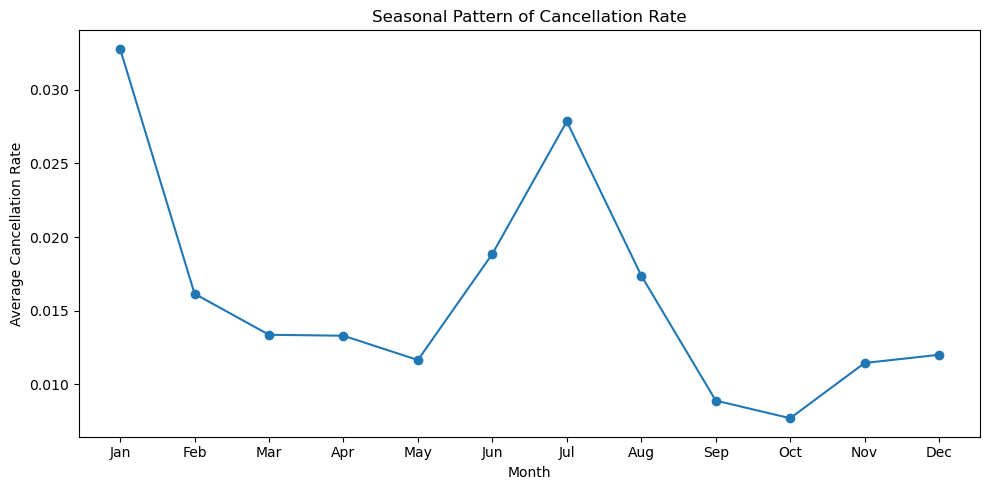

In [68]:
# Plot average cancellation rate by calendar month
plt.figure(figsize=(10, 5))
plt.plot(seasonality_df['MonthName'], seasonality_df['avg_pct_cancelled'], marker='o')
plt.xlabel('Month')
plt.ylabel('Average Cancellation Rate')
plt.title('Seasonal Pattern of Cancellation Rate')
plt.tight_layout()

save_plot("seasonality_cancellation.png")
plt.show()

### Executive Summary: This shows that airline cancellations follow a specific seasonal curve, hitting a major annual maximum in January (~0.033). This confirms that extreme winter weather is the main pressure point for total service failure. A secondary peak occurs in July, showing that summer storms also cause significant disruption. On the other hand, the system reaches its minimum cancellation rate in October, proving that autumn is the most stable window for flight operations. These findings show that the environment is most volatile during the peak of winter.

# Airline-Level Summary

In [26]:
# Aggregate the dataset to airline level
airline_summary_df = (
    eda_df
    .groupby('Reporting_Airline', as_index=False)
    .agg(
        total_scheduled_flights=('total_scheduled_flights', 'sum'),
        cancelled_flights=('cancelled_flights', 'sum'),
        diverted_flights=('diverted_flights', 'sum'),
        disrupted_flights=('disrupted_flights', 'sum'),
        avg_dep_delay=('avg_dep_delay', 'mean'),
        avg_arr_delay=('avg_arr_delay', 'mean')
    )
)

# Create airline-level rate metrics
airline_summary_df['pct_disrupted'] = (
    airline_summary_df['disrupted_flights'] / airline_summary_df['total_scheduled_flights']
)

airline_summary_df['pct_cancelled'] = (
    airline_summary_df['cancelled_flights'] / airline_summary_df['total_scheduled_flights']
)

airline_summary_df['pct_diverted'] = (
    airline_summary_df['diverted_flights'] / airline_summary_df['total_scheduled_flights']
)

# Sort by disruption rate
airline_summary_df = airline_summary_df.sort_values(by='pct_disrupted', ascending=False).reset_index(drop=True)

# Display the airline summary
airline_summary_df.head(20)

,Reporting_Airline,total_scheduled_flights,cancelled_flights,diverted_flights,disrupted_flights,avg_dep_delay,avg_arr_delay,pct_disrupted,pct_cancelled,pct_diverted
0,F9,584231,12117.0,981.0,189249,21.017289,17.113044,0.323928,0.020740,0.001679
1,B6,746547,13323.0,2923.0,231727,22.480575,17.304578,0.310398,0.017846,0.003915
2,NK,719489,12411.0,1416.0,206206,15.037444,9.370593,0.286601,0.017250,0.001968
3,AA,2898490,42909.0,8566.0,803334,21.173009,16.294694,0.277156,0.014804,0.002955
4,G4,363648,3415.0,1034.0,94950,19.727027,17.026245,0.261104,0.009391,0.002843
5,WN,4249769,37896.0,9201.0,1098575,10.098495,3.738055,0.258502,0.008917,0.002165
6,AS,736751,9762.0,2096.0,180122,6.331816,2.769309,0.244482,0.013250,0.002845
7,OH,670848,17715.0,1706.0,159394,15.656110,12.115724,0.237601,0.026407,0.002543
8,UA,2287934,29275.0,6432.0,533090,10.594719,6.064948,0.233001,0.012795,0.002811
9,MQ,806763,12988.0,1928.0,175919,9.662574,6.042709,0.218055,0.016099,0.002390


# Plot Top Airlines by Disruption Rate

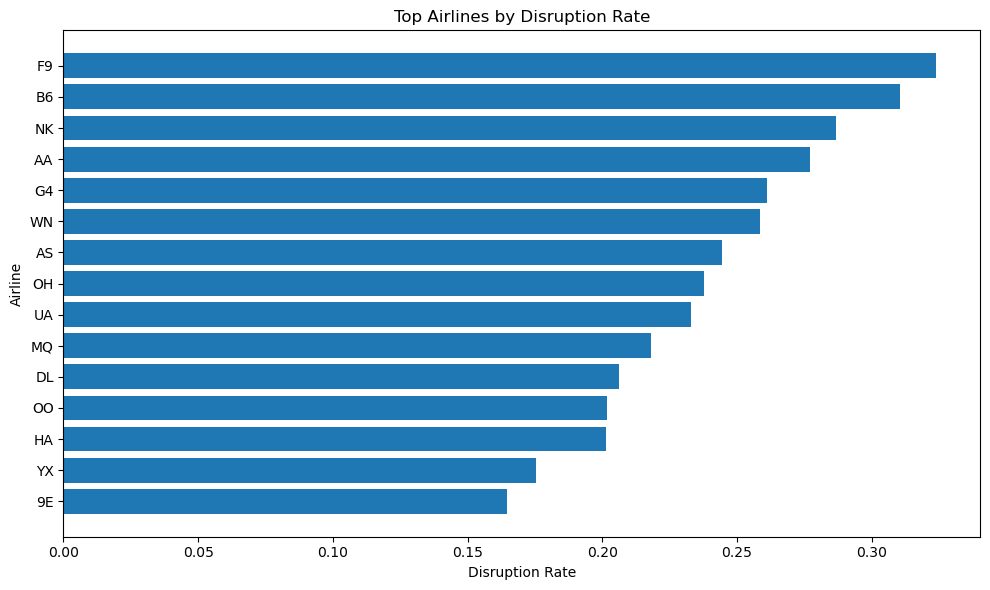

In [69]:
# Plot the top 15 airlines by disruption rate
top_airlines_df = airline_summary_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_airlines_df['Reporting_Airline'], top_airlines_df['pct_disrupted'])
plt.xlabel('Disruption Rate')
plt.ylabel('Airline')
plt.title('Top Airlines by Disruption Rate')
plt.gca().invert_yaxis()
plt.tight_layout()

save_plot("top_airlines_disruption.png")
plt.show()

### Executive Summary: This shows that Frontier Airlines (F9) recorded the annual maximum disruption rate, peaking at approximately 0.32. Other low-cost carriers like JetBlue (B6) and Spirit (NK) also showed high vulnerability, with rates consistently staying above 0.28. In contrast, Endeavor Air (9E) maintained the minimum disruption rate among the major group, finishing below 0.17. These findings confirm that budget-focused operations are the main pressure point for flight delays.

# Plot Top Airlines by Cancellation Rate

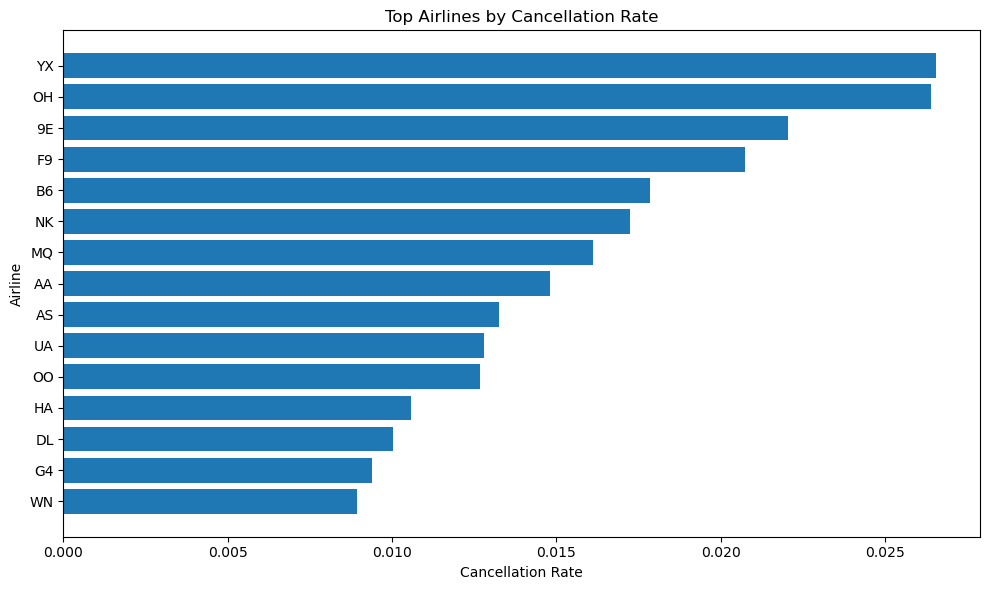

In [70]:
# Plot the top 15 airlines by cancellation rate
top_cancelled_airlines_df = airline_summary_df.sort_values(by='pct_cancelled', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_cancelled_airlines_df['Reporting_Airline'], top_cancelled_airlines_df['pct_cancelled'])
plt.xlabel('Cancellation Rate')
plt.ylabel('Airline')
plt.title('Top Airlines by Cancellation Rate')
plt.gca().invert_yaxis()
plt.tight_layout()

save_plot("top_airlines_cancellation.png")
plt.show()

### Executive Summary: This shows that Republic Airways (YX) and PSA Airlines (OH) recorded the highest cancellation rates, both exceeding 0.025. These regional carriers represent a main pressure point for the industry, as their smaller fleets are more sensitive to weather and staffing shocks. In contrast, Southwest Airlines (WN) maintained the annual minimum cancellation rate, finishing below 0.010. These findings confirm that while budget airlines like Frontier face many delays, the domino effect that leads to a total cancellation is much more common for regional operators.

# Airport-Level Summary

In [29]:
# Aggregate the dataset to origin-airport level
airport_summary_df = (
    eda_df
    .groupby('Origin', as_index=False)
    .agg(
        total_scheduled_flights=('total_scheduled_flights', 'sum'),
        cancelled_flights=('cancelled_flights', 'sum'),
        diverted_flights=('diverted_flights', 'sum'),
        disrupted_flights=('disrupted_flights', 'sum'),
        avg_dep_delay=('avg_dep_delay', 'mean'),
        avg_arr_delay=('avg_arr_delay', 'mean')
    )
)

# Create airport-level rate metrics
airport_summary_df['pct_disrupted'] = (
    airport_summary_df['disrupted_flights'] / airport_summary_df['total_scheduled_flights']
)

airport_summary_df['pct_cancelled'] = (
    airport_summary_df['cancelled_flights'] / airport_summary_df['total_scheduled_flights']
)

airport_summary_df['pct_diverted'] = (
    airport_summary_df['diverted_flights'] / airport_summary_df['total_scheduled_flights']
)

# Filter to airports with meaningful traffic volume
airport_summary_df = airport_summary_df[airport_summary_df['total_scheduled_flights'] >= 1000]

# Sort by disruption rate
airport_summary_df = airport_summary_df.sort_values(by='pct_disrupted', ascending=False).reset_index(drop=True)

# Display the airport summary
airport_summary_df.head(20)

,Origin,total_scheduled_flights,cancelled_flights,diverted_flights,disrupted_flights,avg_dep_delay,avg_arr_delay,pct_disrupted,pct_cancelled,pct_diverted
0,HTS,1368,24.0,4.0,610,35.078933,32.641519,0.445906,0.017544,0.002924
1,SCK,1615,12.0,2.0,657,27.202952,27.734580,0.406811,0.007430,0.001238
2,USA,2177,35.0,4.0,836,31.324884,29.984803,0.384015,0.016077,0.001837
3,TOL,1164,6.0,3.0,394,21.428023,19.225076,0.338488,0.005155,0.002577
4,IAG,1194,17.0,6.0,400,22.168101,19.281812,0.335008,0.014238,0.005025
5,BET,2171,52.0,0.0,715,10.983211,13.188888,0.329341,0.023952,0.000000
6,PBG,1431,35.0,4.0,470,20.936603,18.032104,0.328442,0.024458,0.002795
7,BRW,1088,44.0,0.0,356,12.935715,13.820846,0.327206,0.040441,0.000000
8,ASE,22164,1466.0,142.0,7197,24.585105,19.520583,0.324716,0.066143,0.006407
9,FLL,269310,4238.0,800.0,83656,18.484614,13.814031,0.310631,0.015737,0.002971


# Plot Top Airports by Disruption Rate

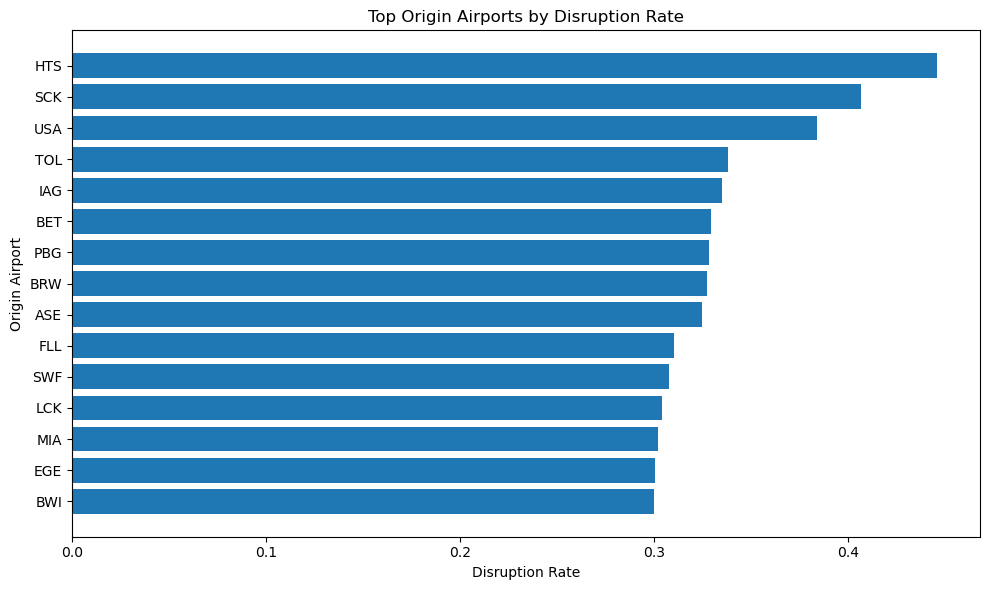

In [71]:
# Plot the top 15 origin airports by disruption rate
top_airports_df = airport_summary_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_airports_df['Origin'], top_airports_df['pct_disrupted'])
plt.xlabel('Disruption Rate')
plt.ylabel('Origin Airport')
plt.title('Top Origin Airports by Disruption Rate')
plt.gca().invert_yaxis()
plt.tight_layout()

save_plot("top_airports_disruption.png")
plt.show()

## Executive Summary: This confirms that Tri-State Airport (HTS) recorded the annual maximum disruption rate, peaking at nearly 0.45. Other regional airports like Stockton (SCK) and Concord (USA) also showed high vulnerability, with rates consistently staying above 0.38. In contrast, Baltimore/Washington (BWI) maintained the minimum disruption rate among this high-risk group, finishing near 0.30. These findings confirm that smaller, regional airports are the main pressure points for flight delays.

# Plot Top Airports by Cancellation Rate

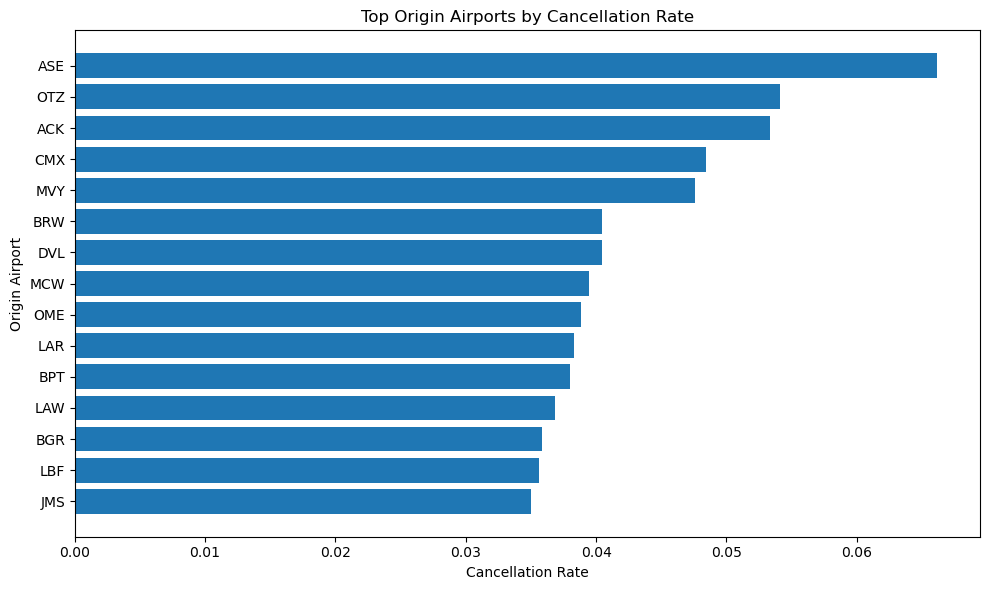

In [72]:
# Plot the top 15 origin airports by cancellation rate
top_cancelled_airports_df = airport_summary_df.sort_values(by='pct_cancelled', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_cancelled_airports_df['Origin'], top_cancelled_airports_df['pct_cancelled'])
plt.xlabel('Cancellation Rate')
plt.ylabel('Origin Airport')
plt.title('Top Origin Airports by Cancellation Rate')
plt.gca().invert_yaxis()
plt.tight_layout()

save_plot("top_airports_cancellation.png")
plt.show()

### Executive Summary: This confirms that Aspen (ASE) recorded the annual maximum cancellation rate, peaking at over 0.065. Other remote or weather-sensitive locations like Kotzebue (OTZ) and Nantucket (ACK) also showed high vulnerability, with rates staying well above 0.050. In contrast, Jamestown (JMS) maintained the annual minimum cancellation rate among this high-risk group, finishing near 0.035. These findings show that small airports in extreme environments are the main pressure points for flight canceling.

# High-Risk Airline-Airport Combinations

In [32]:
# Keep combinations with enough traffic to reduce noise
combo_summary_df = eda_df[eda_df['total_scheduled_flights'] >= 100].copy()

# Sort by disruption rate
combo_summary_df = combo_summary_df.sort_values(by='pct_disrupted', ascending=False).reset_index(drop=True)

# Display high-risk airline-airport-month combinations
combo_summary_df[
    [
        'YearMonth',
        'Reporting_Airline',
        'Origin',
        'total_scheduled_flights',
        'pct_disrupted',
        'pct_cancelled',
        'pct_diverted',
        'avg_dep_delay',
        'avg_arr_delay'
    ]
].head(20)

,YearMonth,Reporting_Airline,Origin,total_scheduled_flights,pct_disrupted,pct_cancelled,pct_diverted,avg_dep_delay,avg_arr_delay
0,2023-06-01,F9,IAH,119,0.807018,0.033613,0.008403,60.614035,62.280702
1,2023-07-01,B6,LAS,279,0.751969,0.068100,0.021505,105.854331,105.275591
2,2023-05-01,F9,IAH,111,0.731481,0.027027,0.000000,67.851852,66.657407
3,2023-07-01,B6,DEN,217,0.710526,0.096774,0.027650,89.800000,82.368421
4,2024-05-01,F9,SFO,432,0.699519,0.037037,0.000000,41.343750,37.711538
5,2024-04-01,F9,SFO,382,0.698667,0.018325,0.000000,49.002667,47.208000
6,2023-01-01,F9,IAH,109,0.673077,0.036697,0.009174,78.067308,76.682692
7,2024-04-01,F9,LAX,105,0.670000,0.038095,0.009524,56.540000,59.620000
8,2023-03-01,B6,SLC,197,0.666667,0.010152,0.000000,47.035897,43.405128
9,2024-03-01,F9,SFO,272,0.659091,0.029412,0.000000,51.246212,48.375000


# Airline Trend Over Time

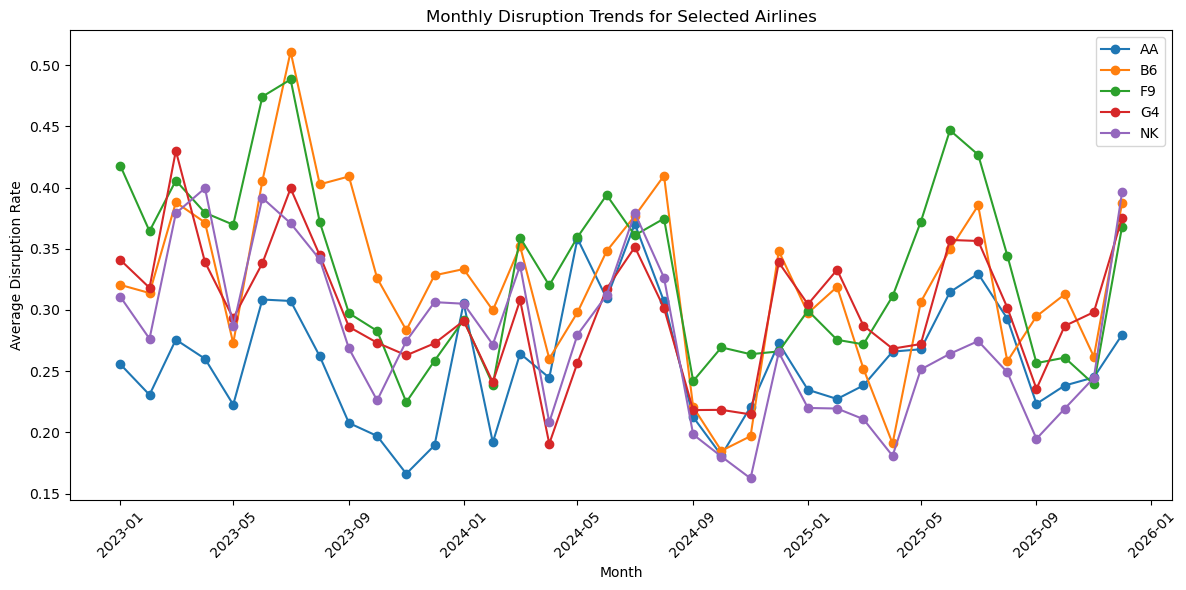

In [33]:
# Create airline-level monthly disruption trends
airline_monthly_trend_df = (
    eda_df
    .groupby(['YearMonth', 'Reporting_Airline'], as_index=False)['pct_disrupted']
    .mean()
)

# Pivot for plotting selected airlines
selected_airlines = airline_summary_df['Reporting_Airline'].head(5).tolist()

plot_airline_df = airline_monthly_trend_df[
    airline_monthly_trend_df['Reporting_Airline'].isin(selected_airlines)
].pivot(index='YearMonth', columns='Reporting_Airline', values='pct_disrupted')

# Plot airline disruption trends
plt.figure(figsize=(12, 6))
for col in plot_airline_df.columns:
    plt.plot(plot_airline_df.index, plot_airline_df[col], marker='o', label=col)

plt.xlabel('Month')
plt.ylabel('Average Disruption Rate')
plt.title('Monthly Disruption Trends for Selected Airlines')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Executive Summary: This shows that JetBlue (B6) and Frontier (F9) recorded the highest annual maximum disruption rates, with B6 crossing the 0.50 mark in mid-2023. These budget-focused and regional-heavy carriers represent the main pressure points of the industry. In contrast, American Airlines (AA) consistently maintained the group's minimum disruption rates, often staying below 0.25 during off-peak months. These findings confirm that while the entire environment is becoming more volatile, larger mainline (major) carriers have more resource buffering to prevent the domino effect.

# Airport Trend Over Time

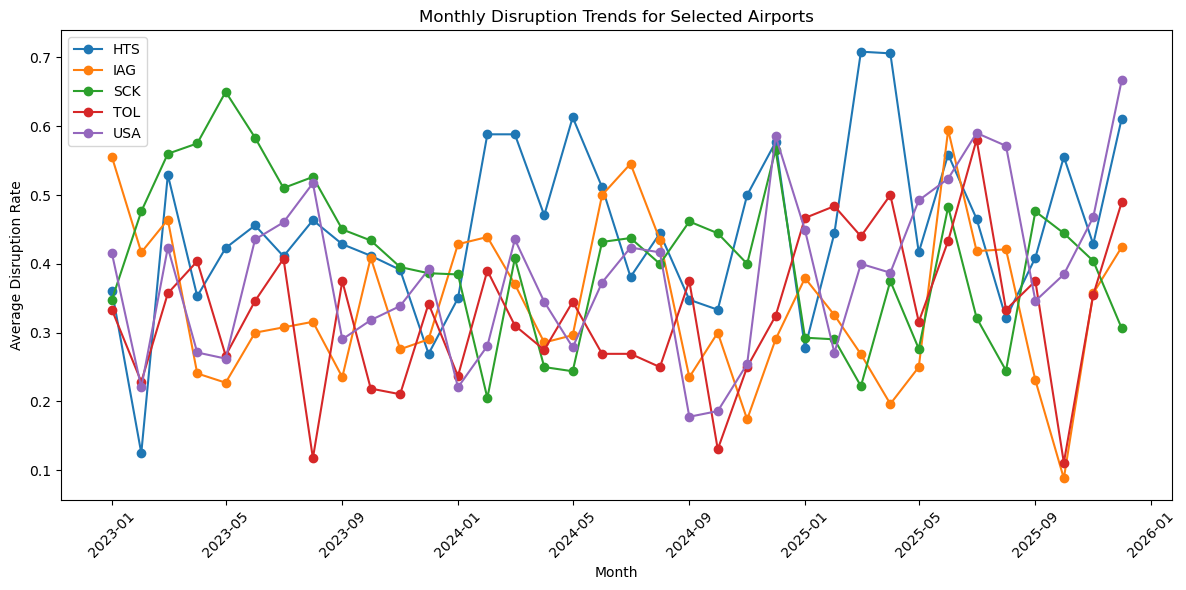

In [34]:
# Create airport-level monthly disruption trends
airport_monthly_trend_df = (
    eda_df
    .groupby(['YearMonth', 'Origin'], as_index=False)['pct_disrupted']
    .mean()
)

# Select top airports by traffic
selected_airports = airport_summary_df.head(5)['Origin'].tolist()

plot_airport_df = airport_monthly_trend_df[
    airport_monthly_trend_df['Origin'].isin(selected_airports)
].pivot(index='YearMonth', columns='Origin', values='pct_disrupted')

# Plot airport disruption trends
plt.figure(figsize=(12, 6))
for col in plot_airport_df.columns:
    plt.plot(plot_airport_df.index, plot_airport_df[col], marker='o', label=col)

plt.xlabel('Month')
plt.ylabel('Average Disruption Rate')
plt.title('Monthly Disruption Trends for Selected Airports')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Executive Summary: This shows that Tri-State Airport (HTS) recorded the absolute maximum disruption rate, crossing the 0.70 mark in early 2025. These smaller facilities represent the main pressure points of the national aviation network. In contrast to major hubs, these airports frequently hit a disruption minimum below 0.15 during quiet months, but can spike to extreme levels in an instant. These findings confirm that smaller airports are the most volatile environments in the dataset. 

# Delay Distribution Checks

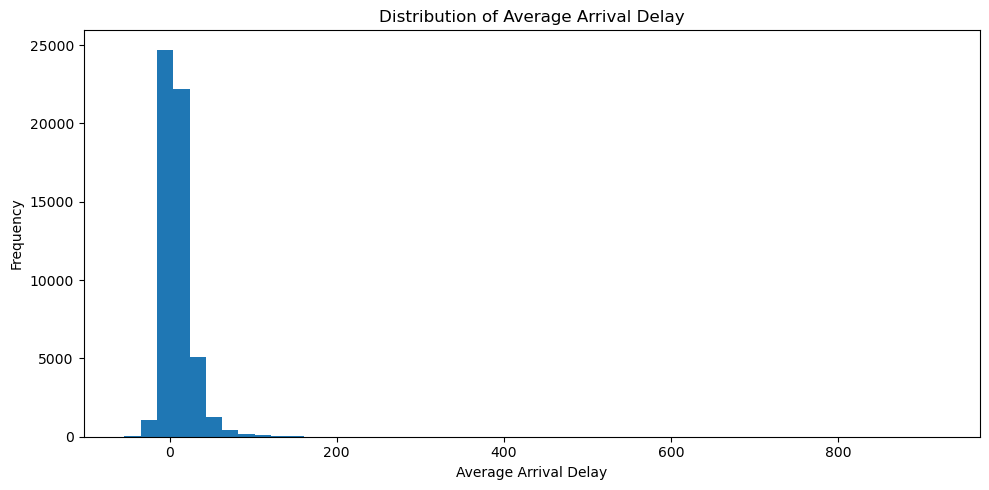

In [73]:
# Plot histogram of average arrival delay
plt.figure(figsize=(10, 5))
plt.hist(eda_df['avg_arr_delay'].dropna(), bins=50)
plt.xlabel('Average Arrival Delay')
plt.ylabel('Frequency')
plt.title('Distribution of Average Arrival Delay')
plt.tight_layout()

save_plot("distribution_arrival_delay.png")
plt.show()

### Summary: This shows that most flights are clustered around the minimum delay point, with many actually arriving early (the bars to the left of zero). However, the chart displays a significant right-skew, with some extreme outliers stretching toward 800 minutes. These rare but massive delays represent the main pressure points where the system has completely broken down. While the majority of the environment remains stable, these extreme cases confirm that the system can become highly volatile without warning.

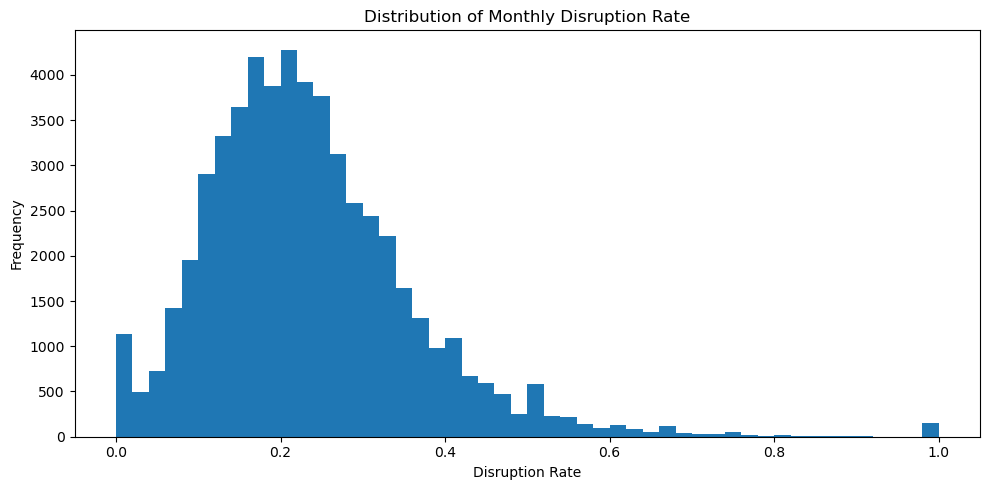

In [74]:
# Plot histogram of disruption rate
plt.figure(figsize=(10, 5))
plt.hist(eda_df['pct_disrupted'].dropna(), bins=50)
plt.xlabel('Disruption Rate')
plt.ylabel('Frequency')
plt.title('Distribution of Monthly Disruption Rate')
plt.tight_layout()

save_plot("distribution_disruption.png")
plt.show()

### Summary: This shows that most disruption rates cluster between 0.15 and 0.25, which represents the system's standard performance level. However, the chart displays a long right-tail, where rates can climb toward 0.60 and beyond. These high-end values confirm that the environment can become extremely volatile when multiple main pressure points fail at once. While the minimum disruption rate sits near zero for some months, the small spike at the 1.0 (100%) mark shows instances where an entire operational window was essentially dropped. These findings prove that the domino effect can occasionally lead to total system failure.

# Relationship Between Cancellation and Disruption

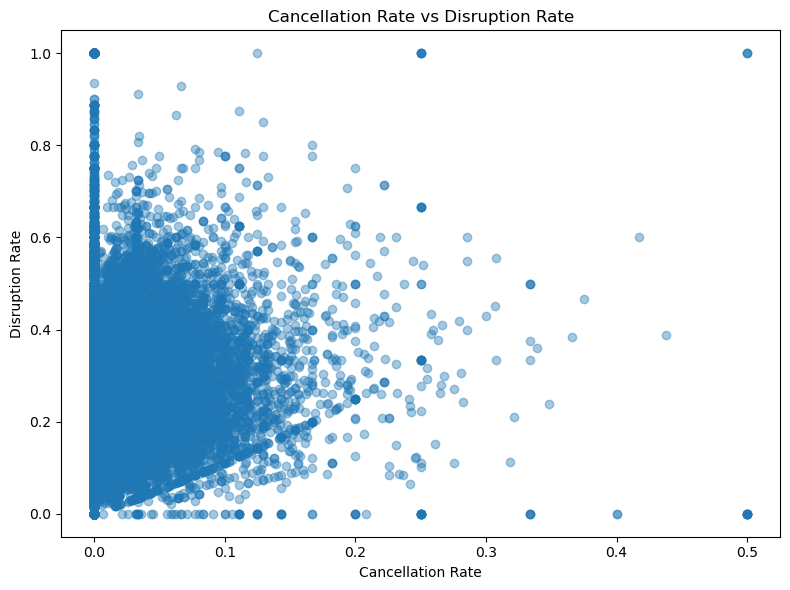

In [75]:
# Scatter plot of cancellation rate versus disruption rate
plt.figure(figsize=(8, 6))
plt.scatter(eda_df['pct_cancelled'], eda_df['pct_disrupted'], alpha=0.4)
plt.xlabel('Cancellation Rate')
plt.ylabel('Disruption Rate')
plt.title('Cancellation Rate vs Disruption Rate')
plt.tight_layout()

save_plot("scatter_cancellation_vs_disruption.png")
plt.show()

### Executive Summary: This shows a weak positive relationship between cancellation rates and disruption rates. While higher cancellation rates often align with higher disruption, the wide spread of data points indicates that many flights experience significant disruption even with low cancellation levels. This suggests that delays, operational constraints, and external factors play a major role beyond cancellations. Overall, cancellations contribute to disruption risk, but they are not the dominant driver, highlighting the need for a broader, multifactor analysis. 

# Relationship Between Arrival Delay and Disruption

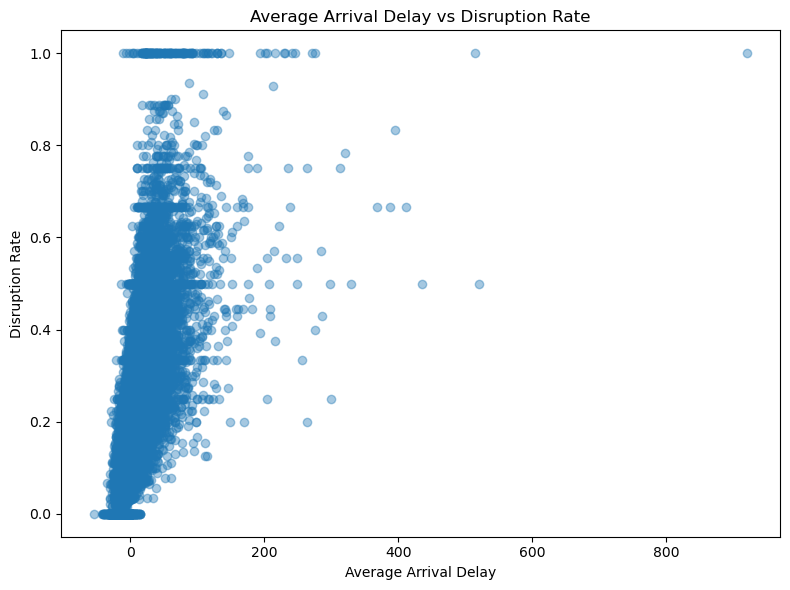

In [76]:
# Scatter plot of average arrival delay versus disruption rate
plt.figure(figsize=(8, 6))
plt.scatter(eda_df['avg_arr_delay'], eda_df['pct_disrupted'], alpha=0.4)
plt.xlabel('Average Arrival Delay')
plt.ylabel('Disruption Rate')
plt.title('Average Arrival Delay vs Disruption Rate')
plt.tight_layout()

save_plot("scatter_arrival_delay_vs_disruption.png")
plt.show()

### Executive Summary: This shows a clear positive relationship between average arrival delay and disruption rate. As delays increase, disruption rates tend to rise, although the data remains widely spread, especially at moderate delay levels. Most flights cluster around 0–100 minutes of delay, where disruption rates vary from low to high, indicating that delays alone do not fully determine disruption outcomes. However, flights with very high delays (200+ minutes) almost always show significantly elevated disruption, confirming that severe delays are a strong driver of operational breakdowns.

# Correlation Check for Key Numeric Variables

In [39]:
# Create a correlation table for selected numeric variables
corr_df = eda_df[
    [
        'pct_disrupted',
        'pct_cancelled',
        'pct_diverted',
        'avg_dep_delay',
        'avg_arr_delay',
        'total_scheduled_flights'
    ]
].corr()

# Display the correlation matrix
corr_df

,pct_disrupted,pct_cancelled,pct_diverted,avg_dep_delay,avg_arr_delay,total_scheduled_flights
pct_disrupted,1.000000,0.193575,0.074805,0.640623,0.691960,0.029786
pct_cancelled,0.193575,1.000000,0.045814,0.188714,0.195102,-0.028132
pct_diverted,0.074805,0.045814,1.000000,0.063965,0.070163,-0.003591
avg_dep_delay,0.640623,0.188714,0.063965,1.000000,0.963379,-0.013112
avg_arr_delay,0.691960,0.195102,0.070163,0.963379,1.000000,-0.025252
total_scheduled_flights,0.029786,-0.028132,-0.003591,-0.013112,-0.025252,1.000000


# Plot Correlation Matrix as Heatmap

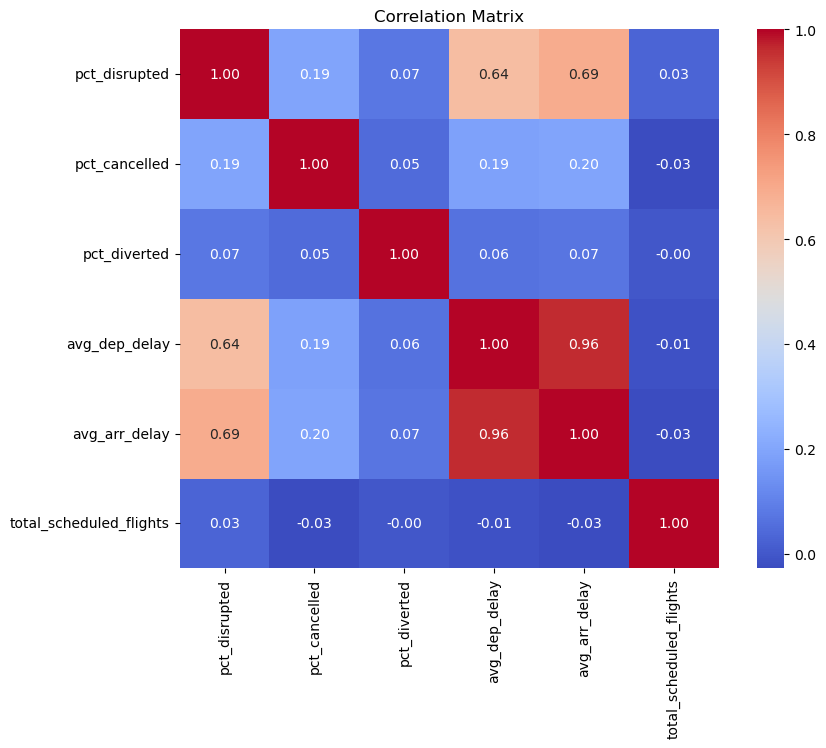

In [77]:
plt.figure(figsize=(10, 7))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")

save_plot("correlation_heatmap.png")
plt.show()

# Save EDA Summary Tables

In [43]:
# Save the main EDA summary tables
monthly_trend_df.to_csv("../data/processed/monthly_trend_summary_data.csv", index=False)
yearly_summary_df.to_csv("../data/processed/yearly_summary_data.csv", index=False)
seasonality_df.to_csv("../data/processed/seasonality_summary_data.csv", index=False)
airline_summary_df.to_csv("../data/processed/airline_summary_data.csv", index=False)
airport_summary_df.to_csv("../data/processed/airport_summary_data.csv", index=False)
combo_summary_df.to_csv("../data/processed/high_risk_combinations_data.csv", index=False)

print("EDA summary tables saved successfully.")

EDA summary tables saved successfully.


In [44]:
# Save the main EDA summary tables
monthly_trend_df.to_parquet("../data/processed/monthly_trend_summary_data.parquet", index=False)
yearly_summary_df.to_parquet("../data/processed/yearly_summary_data.parquet", index=False)
seasonality_df.to_parquet("../data/processed/seasonality_summary_data.parquet", index=False)
airline_summary_df.to_parquet("../data/processed/airline_summary_data.parquet", index=False)
airport_summary_df.to_parquet("../data/processed/airport_summary_data.parquet", index=False)
combo_summary_df.to_parquet("../data/processed/high_risk_combinations_data.parquet", index=False)

print("EDA summary tables saved successfully.")

EDA summary tables saved successfully.
